Using device: cuda
Total samples: 12000
Classes: {'background', 'pre-feeding', 'feeding', 'post-feeding'}

Training CNN...
Epoch 1/10  Loss=0.1751
Epoch 2/10  Loss=0.0720
Epoch 3/10  Loss=0.0384
Epoch 4/10  Loss=0.0335
Epoch 5/10  Loss=0.0290
Epoch 6/10  Loss=0.0244
Epoch 7/10  Loss=0.0262
Epoch 8/10  Loss=0.0156
Epoch 9/10  Loss=0.0113
Epoch 10/10  Loss=0.0210

Evaluating CNN...

--- CNN RESULTS ---
Training time: 373.5781 s
Inference time per sample: 25.9915 ms
Accuracy: 0.9988
Precision: 0.9965
Recall: 0.998
F1-score: 0.9972

Confusion Matrix:
 [[ 180    0    0    0]
 [   0  149    0    1]
 [   0    0  630    0]
 [   0    2    0 1438]]


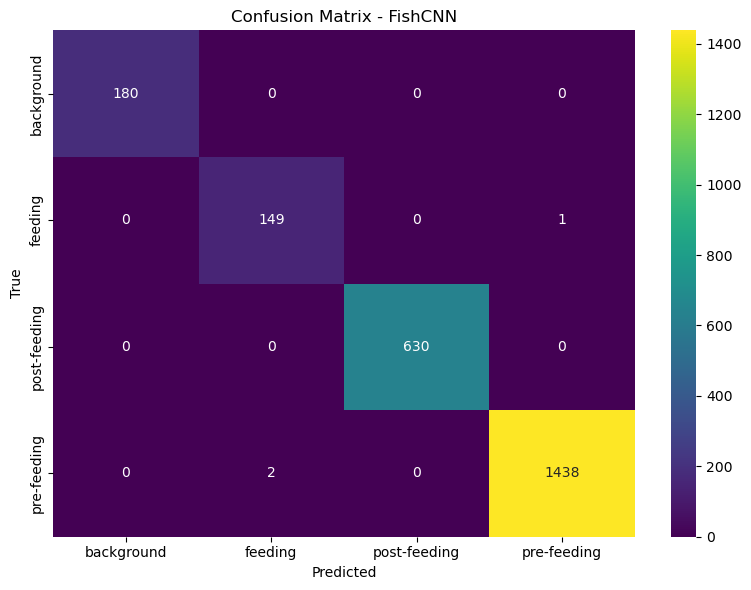

In [11]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_2s"
SAMPLE_RATE = 8000
N_MELS = 128
FMAX = 1000
BATCH_SIZE = 32
EPOCHS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


# ---------------------------------------------------------
# CNN MODEL (FishCNN FROM PAPER)
# ---------------------------------------------------------
class FishCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(FishCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.gap   = nn.AdaptiveAvgPool2d((8, 8))

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))

        x = self.gap(x)
        x = torch.flatten(x, 1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.log_softmax(self.fc2(x), dim=1)


# ---------------------------------------------------------
# FEATURE EXTRACTION - CNN VERSION
# ---------------------------------------------------------
def extract_mel(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)


# ---------------------------------------------------------
# LABEL MAPPING
# ---------------------------------------------------------
def map_label_from_path(path):
    p = path.lower()
    if "background" in p: return "background"
    if "pre" in p and "feed" in p: return "pre-feeding"
    if "post" in p and "feed" in p: return "post-feeding"
    if "feeding" in p: return "feeding"
    return None


# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------
files = []
labels = []

for root, dirs, fs in os.walk(DATASET_PATH):
    for f in fs:
        if f.endswith(".wav"):
            path = os.path.join(root, f)
            lbl = map_label_from_path(root)
            if lbl:
                files.append(path)
                labels.append(lbl)

print("Total samples:", len(files))
print("Classes:", set(labels))


# ---------------------------------------------------------
# LABEL ENCODING
# ---------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)


# ---------------------------------------------------------
# TRAIN TEST SPLIT
# ---------------------------------------------------------
train_files, test_files, y_train, y_test = train_test_split(
    files, y, test_size=0.2, random_state=42, stratify=y
)


# ---------------------------------------------------------
# DATASET CLASS
# ---------------------------------------------------------
class MelDataset(Dataset):
    def __init__(self, filepaths, labels):
        self.f = filepaths
        self.y = labels

    def __len__(self):
        return len(self.f)

    def __getitem__(self, idx):
        mel = extract_mel(self.f[idx])
        mel = torch.tensor(mel).unsqueeze(0)  # shape (1, 128, T)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return mel, label


# ---------------------------------------------------------
# DATA LOADERS
# ---------------------------------------------------------
train_ds = MelDataset(train_files, y_train)
test_ds  = MelDataset(test_files, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


# ---------------------------------------------------------
# MODEL, LOSS, OPTIMIZER
# ---------------------------------------------------------
model = FishCNN(num_classes=4).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# ---------------------------------------------------------
# TRAINING LOOP
# ---------------------------------------------------------
print("\nTraining CNN...")
start_train = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for mel, label in train_dl:
        mel = mel.to(DEVICE)
        label = label.to(DEVICE)

        optimizer.zero_grad()
        out = model(mel)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss={total_loss/len(train_dl):.4f}")

train_time = time.time() - start_train


# ---------------------------------------------------------
# INFERENCE
# ---------------------------------------------------------
print("\nEvaluating CNN...")
model.eval()

y_true = []
y_pred = []

start_inf = time.time()

with torch.no_grad():
    for mel, label in test_dl:
        mel = mel.to(DEVICE)
        out = model(mel)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        y_true.extend(label.numpy())
        y_pred.extend(preds)

inf_time = (time.time() - start_inf) / len(test_ds)


# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
f1   = f1_score(y_true, y_pred, average="macro")
cm   = confusion_matrix(y_true, y_pred)


print("\n--- CNN RESULTS ---")
print("Training time:", round(train_time, 4), "s")
print("Inference time per sample:", round(inf_time * 1000, 4), "ms")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print("\nConfusion Matrix:\n", cm)


# ---------------------------------------------------------
# CONFUSION MATRIX (PLOT)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - FishCNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [2]:
from torch.utils.data import Dataset
import numpy as np
import torch

class MelSpectrogramDataset(Dataset):
    def __init__(self, filepaths, labels):
        self.filepaths = filepaths
        self.labels = labels

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        mel = np.load(self.filepaths[idx])          # shape (128, T)
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)  # (1, 128, T)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    filepaths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

NameError: name 'filepaths' is not defined